
# POWBAL Smart Switch — Comprehensive Exploratory Data Analysis (EDA)



**Notebook type:** Reproducible EDA


This notebook delivers a EDA for the POWBAL dataset.  
It is organized for **high‑volume data** (millions of records) and uses **memory‑aware patterns**.  
The goals are to:
- Understand schema, quality, and distributions.
- Explore **behavioral** patterns (switch-off events, overrides, rewards).
- Inspect **temporal** structure (hour/day-of-week/season).
- Identify **relationships** (numeric correlations; categorical‑numeric effects; categorical‑categorical associations).
- Produce **actionable summaries** to inform subsequent modeling (clustering, autoencoders, LSTM with attention).




In [1]:

# --- 1. Setup & Configuration -----
from __future__ import annotations

import os
import sys
import gc
import textwrap
from typing import Iterable, List, Optional, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats
from scipy.stats import chi2_contingency

# Optional: comment out if not available
try:
    import pyarrow  # ensures pandas uses Arrow dtype if configured
except Exception:
    pyarrow = None

# Display options for readability
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Data path (set this to your full dataset)
DATA_PATH = "data/powbal clean/powbal_clean.csv"  # <-- change if needed





## 2. Utilities — Memory helpers and data loader

The functions below are **safe** (read‑only) and designed for **large CSVs**.  
They attempt to use efficient dtypes and offer sampling switches for heavy steps.


In [2]:

def bytes_to_readable(n_bytes: int) -> str:
    """Convert a byte count into a human‑readable string.

    Parameters
    ----------
    n_bytes : int
        Number of bytes.

    Returns
    -------
    str
        Human-readable representation (e.g., '1.23 GB').

    Examples
    --------
    >>> bytes_to_readable(123456789)
    '117.74 MB'
    """
    for unit in ['B','KB','MB','GB','TB']:
        if n_bytes < 1024.0:
            return f"{n_bytes:3.2f} {unit}"
        n_bytes /= 1024.0
    return f"{n_bytes:3.2f} PB"


def optimize_numeric_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric dtypes to reduce memory footprint without losing information.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.

    Returns
    -------
    pandas.DataFrame
        DataFrame with potentially downcast numeric columns.

    Notes
    -----
    - Integers are downcast to smallest signed/unsigned that can hold the values.
    - Floats are downcast to float32 where safe.
    - Nullable dtypes (e.g., 'Int64') are preserved.
    """
    for col in df.select_dtypes(include=['int64', 'int32', 'int16']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64', 'float32']).columns:
        # Only downcast if there are no extreme magnitudes.
        df[col] = pd.to_numeric(df[col], downcast='float')
    return df


def load_powbal_csv(path: str, use_arrow: bool = True, infer_datetime: bool = False, sample_frac: Optional[float] = None) -> pd.DataFrame:
    """Load the POWBAL dataset from CSV using memory‑aware options.

    Parameters
    ----------
    path : str
        Path to the CSV file.
    use_arrow : bool, default True
        Use Arrow-backed string dtype if available.
    infer_datetime : bool, default False
        If True, attempt to parse 'round_datetime' into a datetime column 'parsed_datetime'.
    sample_frac : float, optional
        If provided (0 < sample_frac <= 1), randomly sample the dataset after load.

    Returns
    -------
    pandas.DataFrame
        Loaded DataFrame with optional datetime parsing and downcast numeric types.

    Examples
    --------
    >>> df = load_powbal_csv(DATA_PATH, infer_datetime=True, sample_frac=0.2)
    """
    read_kwargs = dict(low_memory=False)
    if use_arrow and hasattr(pd, "StringDtype"):
        # Prefer Arrow string for memory/speed if available
        try:
            read_kwargs.update(dtype_backend="pyarrow")
        except TypeError:
            # Older pandas: silently ignore
            pass

    df = pd.read_csv(path, **read_kwargs)
    df = optimize_numeric_dtypes(df)

    if infer_datetime and 'round_datetime' in df.columns:
        # Robust parsing; do not raise on errors
        df['parsed_datetime'] = pd.to_datetime(df['round_datetime'], errors='coerce', utc=False, infer_datetime_format=True)

    if sample_frac is not None and 0 < sample_frac < 1:
        df = df.sample(frac=sample_frac, random_state=RANDOM_STATE)

    return df


def memory_report(df: pd.DataFrame) -> str:
    """Return a memory usage report for the DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame

    Returns
    -------
    str
        Pretty memory usage summary.
    """
    mem = df.memory_usage(deep=True).sum()
    return f"DataFrame memory usage: {bytes_to_readable(mem)}; shape = {df.shape}"



## 3. Schema overview and basic checks

Quick look at shape, types, missingness, and key identifier/time variables.  
These diagnostics help spot obvious issues **before** plotting or computing correlations.


In [3]:

def summarize_schema(df: pd.DataFrame, sample_values: int = 3) -> pd.DataFrame:
    """Build a compact schema summary table.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    sample_values : int, default 3
        How many example values to show per column (best effort).

    Returns
    -------
    pandas.DataFrame
        Schema summary with dtype, missing %, unique count, and examples.
    """
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        missing = s.isna().sum()
        nunique = s.nunique(dropna=True)
        examples = list(s.dropna().unique()[:sample_values])
        rows.append({
            'column': col,
            'dtype': str(s.dtype),
            'non_null': n - missing,
            'missing': missing,
            'missing_pct': round(100.0 * missing / max(n, 1), 2),
            'n_unique': nunique,
            'example_values': examples
        })
    out = pd.DataFrame(rows).sort_values(['dtype','missing_pct','column']).reset_index(drop=True)
    return out


def basic_quality_checks(df: pd.DataFrame, id_cols: Optional[List[str]] = None) -> Dict[str, object]:
    """Run basic data quality checks (duplicates, monotonic timestamps if present).

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    id_cols : list of str, optional
        Columns that should be unique *together* (composite key).

    Returns
    -------
    dict
        Summary of checks.
    """
    results = {}
    # Duplicate rows
    results['n_duplicate_rows'] = int(df.duplicated().sum())

    # Composite key duplicates (if provided)
    if id_cols:
        results['n_key_duplicates'] = int(df.duplicated(subset=id_cols).sum())
    else:
        results['n_key_duplicates'] = None

    # Timestamp sanity (if 'parsed_datetime' exists)
    if 'parsed_datetime' in df.columns:
        results['parsed_datetime_na'] = int(df['parsed_datetime'].isna().sum())
        # (Monotonicity check typically requires per-user sorting; do not enforce globally)
    else:
        results['parsed_datetime_na'] = None

    return results



## 4. Missingness

Visualize missing values to prioritize imputation strategies and to avoid biased correlations.  
We show both a **bar chart** (percentage) and a **sorted table**.


In [4]:

def plot_missingness(df: pd.DataFrame, top_k: Optional[int] = 50, rotate: int = 0) -> None:
    """Plot percentage of missing values per column (descending).

    Parameters
    ----------
    df : pandas.DataFrame
        Input.
    top_k : int, optional
        Plot only the top_k most-missing columns.
    rotate : int, default 0
        Rotation angle for x tick labels.
    """
    miss = df.isna().mean().sort_values(ascending=False) * 100.0
    if top_k is not None:
        miss = miss.head(top_k)
    plt.figure(figsize=(max(10, len(miss) * 0.22), 5))
    ax = miss.plot(kind='bar')
    ax.set_ylabel('Missing (%)')
    ax.set_title('Missingness by Column (Top)')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()


def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """Return a sorted missingness table (% and counts)."""
    n = len(df)
    tbl = pd.DataFrame({
        'missing_pct': df.isna().mean() * 100.0,
        'missing_cnt': df.isna().sum()
    })
    return tbl.sort_values('missing_pct', ascending=False).reset_index().rename(columns={'index':'column'})



## 5. Univariate distributions

Explore key variables individually.  
For numerics, we provide both **linear** and **log1p** options to reveal skewed patterns.  
For categoricals, show **top-K levels** by frequency.


In [5]:

def plot_histograms(df: pd.DataFrame, cols: Optional[List[str]] = None, bins: int = 50, log1p: bool = False) -> None:
    """Plot histograms for numeric columns.

    Parameters
    ----------
    df : pandas.DataFrame
    cols : list of str, optional
        Columns to include. If None, uses all numeric columns.
    bins : int, default 50
        Number of histogram bins.
    log1p : bool, default False
        If True, apply log1p transformation before plotting.
    """
    if cols is None:
        cols = list(df.select_dtypes(include=[np.number]).columns)
    for c in cols:
        series = df[c].dropna()
        if len(series) == 0:
            continue
        data = np.log1p(series) if log1p else series
        plt.figure(figsize=(6,4))
        plt.hist(data, bins=bins)
        plt.xlabel(f"{'log1p(' + c + ')' if log1p else c}")
        plt.ylabel('Count')
        plt.title(f"Histogram: {c}{' (log1p)' if log1p else ''}")
        plt.tight_layout()
        plt.show()


def plot_top_categories(df: pd.DataFrame, col: str, top_k: int = 20) -> None:
    """Plot the top-K categories by frequency for a categorical column.

    Parameters
    ----------
    df : pandas.DataFrame
    col : str
        Categorical column name.
    top_k : int, default 20
        Number of categories to display.
    """
    vc = df[col].astype('object').value_counts(dropna=False).head(top_k)
    plt.figure(figsize=(max(10, len(vc) * 0.35), 5))
    ax = vc.plot(kind='bar')
    ax.set_ylabel('Count')
    ax.set_title(f"Top-{top_k} categories: {col}")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



## 6. Temporal patterns (hour/day/week/season)

We aggregate consumption and behavioral outcomes over **time-of-day**, **day-of-week**, and **calendar week**.  
This helps spot **peak demand windows**, **event clustering**, and **override behavior**.


In [6]:

def ensure_parsed_datetime(df: pd.DataFrame, col: str = 'round_datetime', out_col: str = 'parsed_datetime') -> pd.DataFrame:
    """Ensure there is a parsed datetime column.

    If 'out_col' already exists, the function returns df unchanged.

    Parameters
    ----------
    df : pandas.DataFrame
    col : str, default 'round_datetime'
    out_col : str, default 'parsed_datetime'

    Returns
    -------
    pandas.DataFrame
    """
    if out_col in df.columns:
        return df
    if col in df.columns:
        df[out_col] = pd.to_datetime(df[col], errors='coerce', utc=False, infer_datetime_format=True)
    return df


def add_time_parts(df: pd.DataFrame, dt_col: str = 'parsed_datetime') -> pd.DataFrame:
    """Add common temporal parts (hour, dow, week, month)."""
    if dt_col not in df.columns:
        return df
    dt = df[dt_col]
    df['hour'] = dt.dt.hour
    df['half_hour'] = dt.dt.minute // 30
    df['dayofweek'] = dt.dt.dayofweek  # Monday=0
    df['week'] = dt.dt.isocalendar().week.astype(int)
    df['month'] = dt.dt.month
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    return df


def plot_by_hour(df: pd.DataFrame, value_col: str = 'power', outcome_col: Optional[str] = None) -> None:
    """Plot average `value_col` by hour (and optional event/override rates).

    Parameters
    ----------
    df : pandas.DataFrame
    value_col : str, default 'power'
        Numeric variable to aggregate (mean).
    outcome_col : str, optional
        Binary outcome to aggregate as mean (rate), e.g., 'override' or 'actual_event'.
    """
    if 'hour' not in df.columns:
        return
    agg = df.groupby('hour')[value_col].mean().reindex(range(24))
    plt.figure(figsize=(7,4))
    plt.plot(agg.index, agg.values, marker='o')
    plt.title(f"Average {value_col} by Hour")
    plt.xlabel('Hour of day')
    plt.ylabel(f"Mean {value_col}")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    if outcome_col and outcome_col in df.columns:
        rate = df.groupby('hour')[outcome_col].mean().reindex(range(24))
        plt.figure(figsize=(7,4))
        plt.plot(rate.index, rate.values, marker='o')
        plt.title(f"{outcome_col} rate by Hour")
        plt.xlabel('Hour of day')
        plt.ylabel(f"Mean {outcome_col}")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.tight_layout()
        plt.show()


def plot_by_dayofweek(df: pd.DataFrame, value_col: str = 'power', outcome_col: Optional[str] = None) -> None:
    """Plot mean value by day of week (and optional outcome rate)."""
    if 'dayofweek' not in df.columns:
        return
    idx = range(7)
    agg = df.groupby('dayofweek')[value_col].mean().reindex(idx)
    plt.figure(figsize=(7,4))
    plt.plot(agg.index, agg.values, marker='o')
    plt.title(f"Average {value_col} by Day of Week (Mon=0)")
    plt.xlabel('Day of week')
    plt.ylabel(f"Mean {value_col}")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    if outcome_col and outcome_col in df.columns:
        rate = df.groupby('dayofweek')[outcome_col].mean().reindex(idx)
        plt.figure(figsize=(7,4))
        plt.plot(rate.index, rate.values, marker='o')
        plt.title(f"{outcome_col} rate by Day of Week (Mon=0)")
        plt.xlabel('Day of week')
        plt.ylabel(f"Mean {outcome_col}")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.tight_layout()
        plt.show()



## 7. Relationships

We examine numeric‑numeric **correlations** (Pearson/Spearman), categorical‑numeric effects (box/mean plots), and categorical‑categorical **associations** via **Cramér's V**.
To keep visuals readable on a large schema, we select **top‑variance** numeric features and allow **sampling**.


In [7]:

def select_numeric_for_corr(df: pd.DataFrame, max_features: int = 40, missing_threshold: float = 0.4) -> List[str]:
    """Select numeric columns for correlation heatmaps.

    Strategy
    --------
    - Filter numeric columns.
    - Drop columns with missing ratio > `missing_threshold`.
    - Pick top `max_features` by variance (proxy for information).

    Parameters
    ----------
    df : pandas.DataFrame
    max_features : int, default 40
    missing_threshold : float, default 0.4

    Returns
    -------
    list of str
        Selected column names.
    """
    num_cols = df.select_dtypes(include=[np.number]).columns
    if not len(num_cols):
        return []
    miss_ratio = df[num_cols].isna().mean()
    keep = miss_ratio[miss_ratio <= missing_threshold].index
    if not len(keep):
        keep = num_cols  # fallback
    variances = df[keep].var(numeric_only=True).sort_values(ascending=False)
    cols = list(variances.head(max_features).index)
    return cols


def compute_correlation(df: pd.DataFrame, cols: List[str], method: str = 'pearson', sample_n: Optional[int] = 400_000) -> pd.DataFrame:
    """Compute correlation on selected columns with optional row sampling.

    Parameters
    ----------
    df : pandas.DataFrame
    cols : list of str
        Numeric columns to correlate.
    method : {'pearson','spearman'}
    sample_n : int, optional
        If provided, randomly sample up to `sample_n` rows for efficiency.

    Returns
    -------
    pandas.DataFrame
        Correlation matrix (DataFrame).

    Notes
    -----
    For very large datasets, random sampling typically preserves correlation structure
    and significantly reduces compute time.
    """
    data = df[cols]
    if sample_n is not None and len(data) > sample_n:
        data = data.sample(n=sample_n, random_state=RANDOM_STATE)
    corr = data.corr(method=method, numeric_only=True)
    return corr


def plot_correlation_heatmap(corr: pd.DataFrame, title: str = 'Correlation Matrix', annotate: bool = True) -> None:
    """Plot a triangular correlation heatmap using matplotlib only.

    Parameters
    ----------
    corr : pandas.DataFrame
        Square correlation matrix.
    title : str
        Plot title.
    annotate : bool, default True
        Whether to annotate upper‑triangle cells with numeric values.

    Notes
    -----
    Uses a diverging colormap by default to emphasize negative/positive correlations.
    """
    # Mask the upper triangle to plot a lower‑triangle heatmap
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(max(8, 0.35 * len(corr)), max(6, 0.35 * len(corr))))
    im = ax.imshow(np.where(mask, np.nan, corr.values), vmin=-1, vmax=1, cmap='coolwarm')

    # Ticks/labels
    ax.set_xticks(np.arange(len(corr)))
    ax.set_yticks(np.arange(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate
    if annotate and len(corr) <= 60:  # avoid over‑crowding
        for i in range(len(corr)):
            for j in range(len(corr)):
                if i >= j:  # lower triangle incl. diagonal
                    val = corr.values[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f"{val:0.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()


def cramers_v(x: pd.Series, y: pd.Series, bias_correction: bool = True) -> float:
    """Compute Cramér's V association between two categorical variables.

    Parameters
    ----------
    x, y : pandas.Series
        Categorical variables.
    bias_correction : bool, default True
        Apply bias correction (recommended for small tables).

    Returns
    -------
    float
        Cramér's V in [0, 1].
    """
    confusion = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion)
    n = confusion.values.sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    if bias_correction:
        phi2_corr = max(0, phi2 - ((k - 1)*(r - 1))/(n - 1))
        r_corr = r - ((r - 1)**2) / (n - 1)
        k_corr = k - ((k - 1)**2) / (n - 1)
        return np.sqrt(phi2_corr / max(1e-12, min(k_corr - 1, r_corr - 1)))
    else:
        return np.sqrt(phi2 / max(1e-12, min(k - 1, r - 1)))


def numeric_by_category(df: pd.DataFrame, num_col: str, cat_col: str, top_k: int = 10) -> pd.DataFrame:
    """Aggregate a numeric by the top-K most frequent categories (mean, count)."""
    top_levels = df[cat_col].astype('object').value_counts().head(top_k).index
    sub = df[df[cat_col].isin(top_levels)]
    agg = sub.groupby(cat_col)[num_col].agg(['count','mean','std']).sort_values('mean', ascending=False)
    return agg


def plot_box_numeric_by_category(df: pd.DataFrame, num_col: str, cat_col: str, top_k: int = 10) -> None:
    """Boxplot of a numeric variable split by top-K categories using matplotlib."""
    top_levels = df[cat_col].astype('object').value_counts().head(top_k).index
    sub = df[df[cat_col].isin(top_levels)]
    data = [sub[sub[cat_col] == lvl][num_col].dropna().values for lvl in top_levels]
    plt.figure(figsize=(max(8, 0.8 * len(top_levels)), 5))
    plt.boxplot(data, labels=list(top_levels), showmeans=True, meanline=True)
    plt.title(f"{num_col} by {cat_col} (Top {top_k})")
    plt.ylabel(num_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



## 8. Event‑centric analysis (switch‑off windows, overrides, rewards)

Domain‑focused summaries around switch‑off **events**:  
- Identify event windows using `switch_off_F*` (past) and `switch_off_L*` (future) flags.  
- Compare **pre** vs **during** (and **post**) consumption.  
- Relate **override** rates and **reward_rate** / **notice_time**.


In [8]:

def detect_event_row(df: pd.DataFrame, past_prefix: str = 'switch_off_F', future_prefix: str = 'switch_off_L') -> pd.Series:
    """Return a boolean Series marking rows that are within any switch‑off window.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing columns like 'switch_off_F1'...'switch_off_F16' and 'switch_off_L1'...'switch_off_L6'.
    past_prefix : str, default 'switch_off_F'
    future_prefix : str, default 'switch_off_L'

    Returns
    -------
    pandas.Series (bool)
        True if the row is inside an event window.
    """
    past_cols = [c for c in df.columns if c.startswith(past_prefix)]
    future_cols = [c for c in df.columns if c.startswith(future_prefix)]
    cols = past_cols + future_cols
    if not cols:
        return pd.Series(False, index=df.index)
    window = df[cols].fillna(0).astype(int).sum(axis=1) > 0
    return window


def summarize_event_windows(df: pd.DataFrame, value_col: str = 'power') -> pd.DataFrame:
    """Summarize value distributions in/out of event windows and override / actual_event rates.

    Parameters
    ----------
    df : pandas.DataFrame
    value_col : str, default 'power'

    Returns
    -------
    pandas.DataFrame
        Summary table with means and counts.
    """
    window = detect_event_row(df)
    out = []
    for label, mask in [('in_window', window), ('out_window', ~window)]:
        sub = df[mask]
        row = {
            'segment': label,
            'n_rows': len(sub),
            f'mean_{value_col}': sub[value_col].mean(skipna=True) if value_col in sub.columns else np.nan,
            'override_rate': sub['override'].mean(skipna=True) if 'override' in sub.columns else np.nan,
            'event_rate': sub['actual_event'].mean(skipna=True) if 'actual_event' in sub.columns else np.nan,
            'mean_reward_rate': sub['reward_rate'].mean(skipna=True) if 'reward_rate' in sub.columns else np.nan,
            'mean_notice_time': sub['notice_time'].mean(skipna=True) if 'notice_time' in sub.columns else np.nan,
        }
        out.append(row)
    return pd.DataFrame(out)


def pre_post_event_delta(df: pd.DataFrame, value_col: str = 'power', pre_col: str = 'pre_switch_off_reading') -> pd.DataFrame:
    """Compare `pre_switch_off_reading` with value during event windows.

    Parameters
    ----------
    df : pandas.DataFrame
    value_col : str, default 'power'
    pre_col : str, default 'pre_switch_off_reading'

    Returns
    -------
    pandas.DataFrame
        Table with deltas for rows inside event windows where pre readings exist.
    """
    window = detect_event_row(df)
    sub = df.loc[window].copy()
    if pre_col not in sub.columns or value_col not in sub.columns:
        return pd.DataFrame()
    sub = sub[[pre_col, value_col]].dropna()
    sub['delta'] = sub[value_col] - sub[pre_col]
    return sub.describe().T[['mean','std','min','25%','50%','75%','max']]



## 9. User‑level summaries

Aggregate by user to explore **heterogeneity**: energy consumption distribution, override rates, event participation, rewards.  
These summaries are helpful for **clustering** and for defining **personas**.


In [9]:

def user_level_summary(df: pd.DataFrame, user_col: str = 'user_id',
                       value_cols: Optional[List[str]] = None,
                       rate_cols: Optional[List[str]] = None) -> pd.DataFrame:
    """Aggregate per user.

    Parameters
    ----------
    df : pandas.DataFrame
    user_col : str, default 'user_id'
    value_cols : list of str, optional
        Numeric columns to aggregate as mean/sum.
    rate_cols : list of str, optional
        Binary columns to aggregate as mean (rate).

    Returns
    -------
    pandas.DataFrame
        Per‑user aggregated features.
    """
    if user_col not in df.columns:
        raise KeyError(f"user column '{user_col}' not present.")
    aggs: Dict[str, List] = {}
    if value_cols:
        for c in value_cols:
            aggs[c] = ['mean','sum']
    if rate_cols:
        for c in rate_cols:
            aggs[c] = ['mean']
    out = df.groupby(user_col).agg(aggs)
    # flatten columns
    out.columns = ['_'.join(filter(None, map(str, c))).strip('_') for c in out.columns.values]
    out = out.reset_index()
    return out


def plot_user_distribution(df_user: pd.DataFrame, col: str) -> None:
    """Plot a histogram of a per‑user feature (with optional log scale)."""
    if col not in df_user.columns:
        return
    series = df_user[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(series, bins=50)
    plt.title(f"User‑level distribution: {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()



## 11. Run the EDA

This section loads the full dataset, prints a memory report, and executes the key diagnostics.  
Long‑running or heavy operations use **row sampling** and **feature selection** to remain tractable.


In [11]:

# --- Load data ---------------------------------------------------------------
df = load_powbal_csv(DATA_PATH, infer_datetime=True)
print(memory_report(df))
df.head(3)


/var/tmp/pbs.887622.pbs-7/ipykernel_139896/2556612053.py:90: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['parsed_datetime'] = pd.to_datetime(df['round_datetime'], errors='coerce', utc=False, infer_datetime_format=True)
/var/tmp/pbs.887622.pbs-7/ipykernel_139896/2556612053.py:90: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['parsed_datetime'] = pd.to_datetime(df['round_datetime'], errors='coerce', utc=False, infer_datetime_format=True)


DataFrame memory usage: 3.58 GB; shape = (7391239, 135)


,power,schedule_id,ca_number,ca_number_str,timestamp,off,on,reward_rate,notify_participant_at,posted_to_api,reward,device_id,registered_at,deactivated_at,appliance,preference,surveyanswer,power_nonzero,timestamp_id,device_count,total_power,total_power_kW,datetime,switch_off,switch_on,notification,switch_off_time,switch_on_time,notification_time,switch_off_hour,notification_hour,notice_time,date,month,monthofyear,week,weekofyear,day,switch_off_event,start_event,end_event,first_occurence,first_occurence_date,first_occurence_week,week_in_trial,round_datetime,hour,minute,minute_all,half_hour,period_duration,minute_str,halfhourid,energy,energy_Wh,average_power_before_switchoff,mean_W_before_switchoff,hourly_energy_Wh,hourly_energy_kWh,daily_energy_Wh,daily_energy_kWh,weekly_energy_Wh,weekly_energy_kWh,monthly_energy_Wh,monthly_energy_kWh,week_in_trial_energy_Wh,week_in_trial_energy_kWh,avoided_energy_consumption_Wh,obs,group,total_device_count,total_installed_devices,total_online_device_count,device_readings,device_online_atleastonce,devices_online_atleastonce,total_devices_online_atleastonce,share_devices_online_week,share_devices_online,_fillin,switch_off_L1,switch_off_L2,switch_off_L3,switch_off_L4,switch_off_L5,switch_off_L6,switch_off_F1,switch_off_F2,switch_off_F3,switch_off_F4,switch_off_F5,switch_off_F6,switch_off_F7,switch_off_F8,switch_off_F9,switch_off_F10,switch_off_F11,switch_off_F12,switch_off_F13,switch_off_F14,switch_off_F15,switch_off_F16,notice_time_start,notice_time_F1,notice_time_F2,notice_time_F3,notice_time_F4,notice_time_F5,notice_time_F6,notice_time_F7,notice_time_F8,notice_time_F9,notice_time_F10,notice_time_F11,notice_time_F12,notice_time_F13,notice_time_F14,notice_time_F15,notice_time_F16,reward_rate_start,reward_rate_F1,reward_rate_F2,reward_rate_F3,device_reading_count,share_time_device_online,pre_switch_off_reading,reward2,daily_reward,weekly_reward,actual_event,override,number_events_week,number_events_date,city,parsed_datetime
0,66.309998,<NA>,60000191183,60000191183,2023-10-17 04:00,<NA>,<NA>,0,<NA>,<NA>,<NA>,6931403,2023-10-13 14:39:18.136454,None,Refrigerator,Turn on,Turn on,66.309998,120641,374,5648.1001,5.6481,17oct2023 09:30:46,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,17oct2023,202310,10,2023w42,42,Tuesday,0,0,0,17oct2023 09:26:24,17oct2023,2023w42,1,17oct2023 09:30:00,9,30,30,20,5,0,2,5.525833,18.474167,<NA>,<NA>,18.474167,0.018474,775.46252,0.775463,4902.2427,4.902243,4902.2427,4.902243,4902.2427,4.902243,<NA>,1565754,529,529,579,402,148,1,374,402,69.430054,70.699432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,148,44.047619,<NA>,<NA>,0.0,0.0,0,0,0,0,Delhi,2023-10-17 09:30:00
1,70.660004,<NA>,60000191183,60000191183,2023-10-17 04:31,<NA>,<NA>,0,<NA>,<NA>,<NA>,6931403,2023-10-13 14:39:18.136454,None,Refrigerator,Turn on,Turn on,70.660004,120653,377,7878.5898,7.87859,17oct2023 10:01:21,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,17oct2023,202310,10,2023w42,42,Tuesday,0,0,0,17oct2023 09:26:24,17oct2023,2023w42,1,17oct2023 10:00:00,10,0,1,21,5,31,1,5.888334,29.34,<NA>,<NA>,29.34,0.02934,775.46252,0.775463,4902.2427,4.902243,4902.2427,4.902243,4902.2427,4.902243,<NA>,1565754,529,550,579,402,148,1,356,402,69.430054,68.545456,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,148,44.047619,66.309998,<NA>,0.0,0.0,0,0,0,0,Delhi,2023-10-17 10:00:00
2,28.690001,<NA>,60000191183,60000191183,2023-10-17 06:00,<NA>,<NA>,0,<NA>,<NA>,<NA>,6931403,2023-10-13 14:39:18.136454,None,Refrigerator,Turn on,Turn on,28.690001,120725,380,12847.49,12.84749,17oct2023 11:30:55,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,17oct2023,202310,10,2023w42,42,Tuesday,0,0,0,17oct2023 09:26:24,17oct2023,2023w42,1,17oct2023 11:30:00,11,30,30,24,5,0,2,2.390833,14.6675,<NA>,<NA>,14.6675,0.014667,775.46252,0.775463,4902.2427,4.902243,4902.2427,4.902243,4902.2427,4.902243,<NA>,1565754,529,551,579,402,148,1,380,402,69.430054,68.965515,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [12]:

# --- Schema summary & basic checks ------------------------------------------
schema_tbl = summarize_schema(df)
schema_tbl.head(20)


,column,dtype,non_null,missing,missing_pct,n_unique,example_values
0,parsed_datetime,datetime64[ns],7391239,0,0.0,23212,"[2023-10-17 09:30:00, 2023-10-17 10:00:00, 2023-10-17 11:30:00]"
1,daily_energy_Wh,double[pyarrow],7391239,0,0.0,114698,"[775.46252, 1111.8083, 1396.0675]"
2,monthly_energy_Wh,double[pyarrow],7391239,0,0.0,6644,"[4902.2427, 132294.02, 183931.7]"
3,total_power,double[pyarrow],7391239,0,0.0,26656,"[5648.1001, 7878.5898, 12847.49]"
4,week_in_trial_energy_Wh,double[pyarrow],7391239,0,0.0,22454,"[4902.2427, 24967.658, 56147.594]"
5,weekly_energy_Wh,double[pyarrow],7391239,0,0.0,22454,"[4902.2427, 24967.658, 56147.594]"
6,daily_energy_kWh,float[pyarrow],7391239,0,0.0,114695,"[0.7754625082015991, 1.1118083000183105, 1.396067500114441]"
7,daily_reward,float[pyarrow],7391239,0,0.0,2604,"[0.0, 0.5, 0.009999999776482582]"
8,energy_Wh,float[pyarrow],7391239,0,0.0,820632,"[18.474166870117188, 29.34000015258789, 14.667499542236328]"
9,hourly_energy_Wh,float[pyarrow],7391239,0,0.0,697463,"[18.474166870117188, 29.34000015258789, 14.667499542236328]"


In [13]:

quality = basic_quality_checks(df, id_cols=[c for c in ['user_id','parsed_datetime'] if c in df.columns])
quality


{'n_duplicate_rows': 0, 'n_key_duplicates': 7368027, 'parsed_datetime_na': 0}

In [14]:

# --- Missingness -------------------------------------------------------------
missing_tbl = missing_table(df)
missing_tbl.head(30)


,column,missing_pct,missing_cnt
0,deactivated_at,100.000000,7391239
1,average_power_before_switchoff,98.966655,7314862
2,reward2,98.247736,7261725
3,mean_W_before_switchoff,96.351613,7121578
4,avoided_energy_consumption_Wh,96.333429,7120234
5,reward,96.333429,7120234
6,schedule_id,96.333389,7120231
7,notification_hour,96.333389,7120231
8,switch_off_hour,96.333389,7120231
9,notification_time,96.333389,7120231


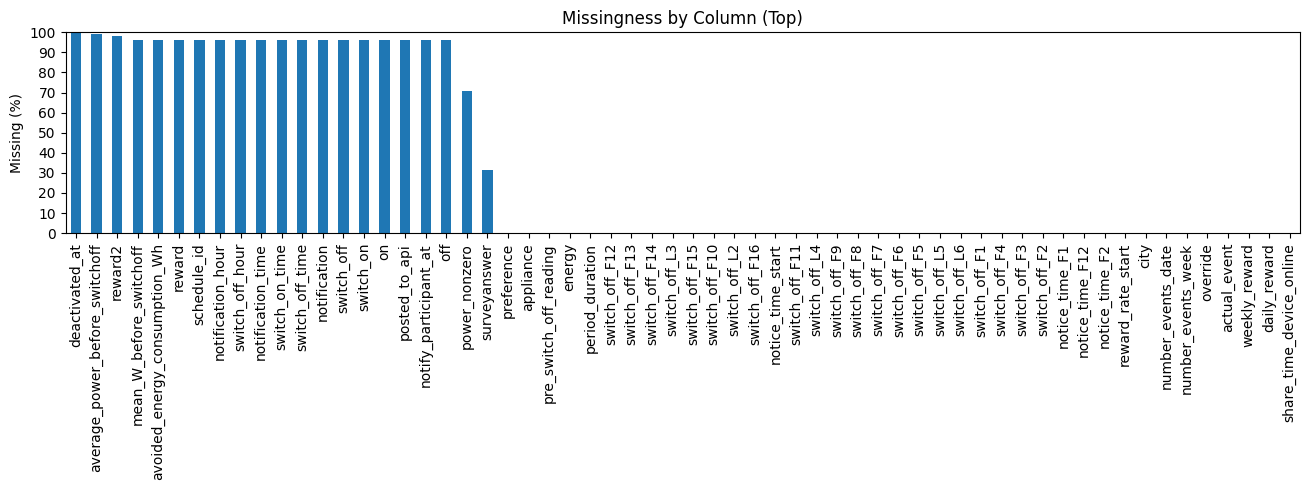

In [15]:

plot_missingness(df, top_k=60, rotate=90)


In [16]:

# --- Temporal parts ----------------------------------------------------------
df = ensure_parsed_datetime(df)
df = add_time_parts(df)


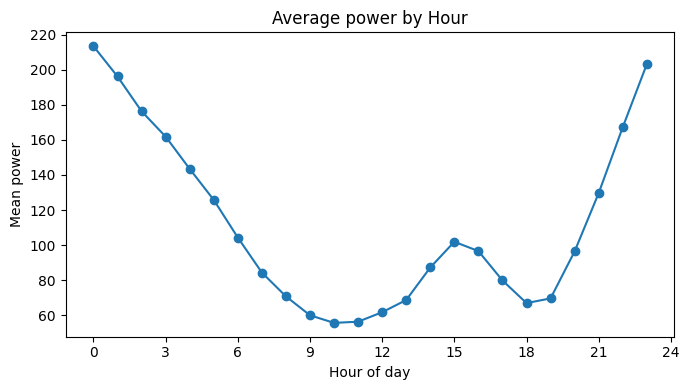

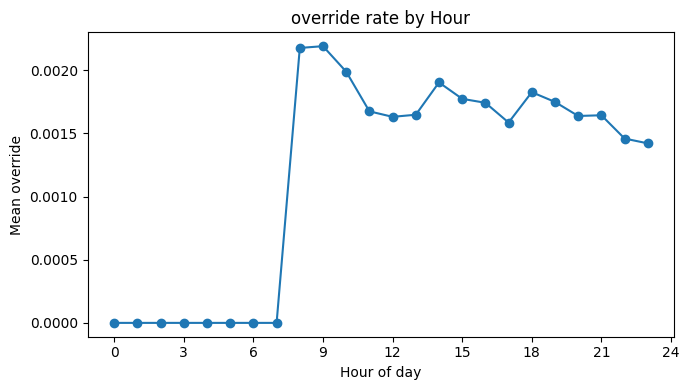

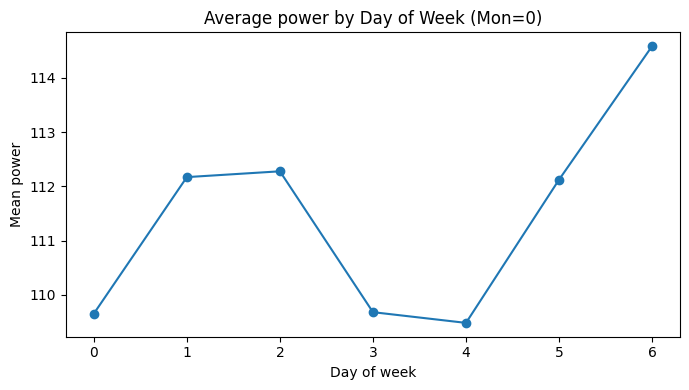

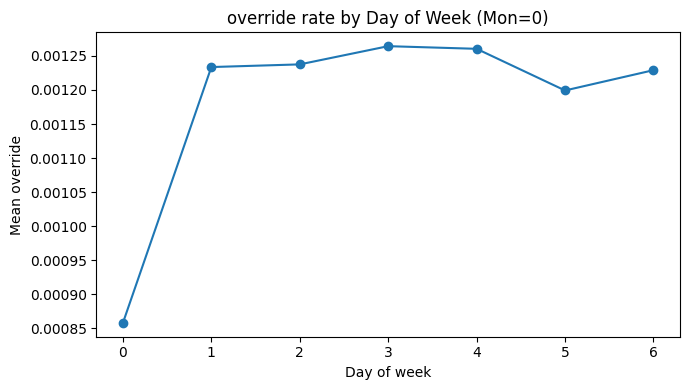

In [17]:

# Plot temporal aggregates for core variables (adjust as needed)
if 'power' in df.columns:
    plot_by_hour(df, value_col='power', outcome_col='override' if 'override' in df.columns else None)
    plot_by_dayofweek(df, value_col='power', outcome_col='override' if 'override' in df.columns else None)


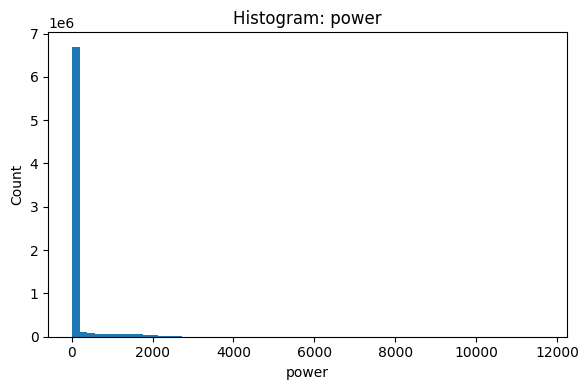

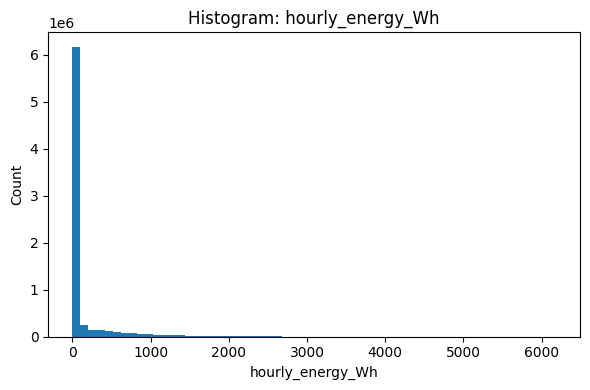

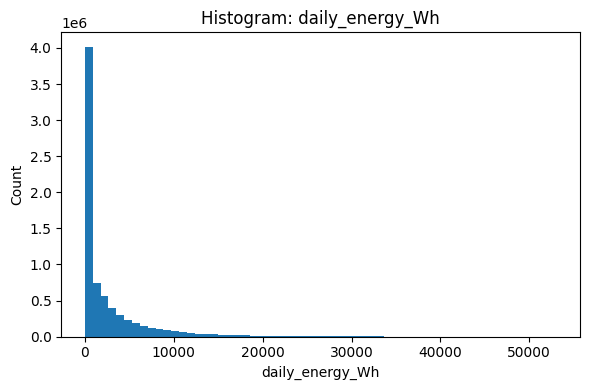

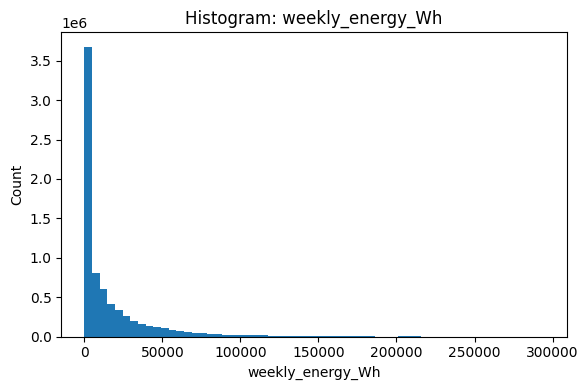

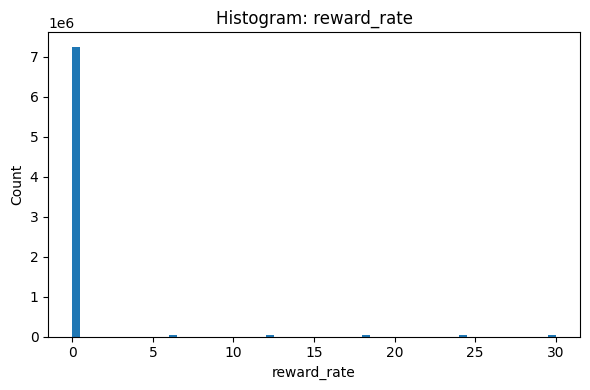

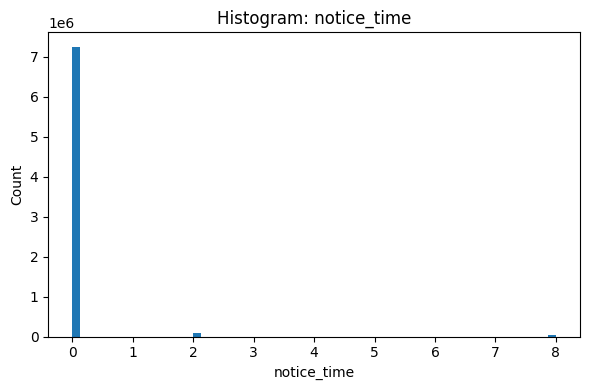

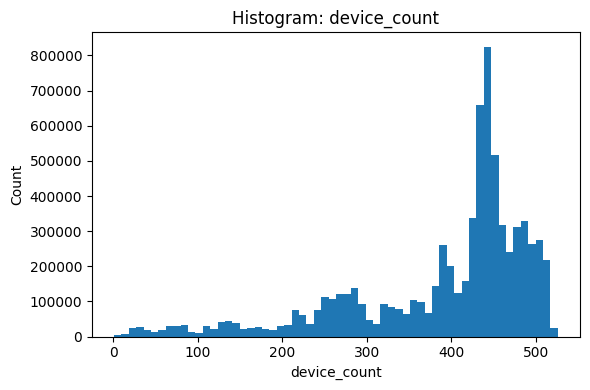

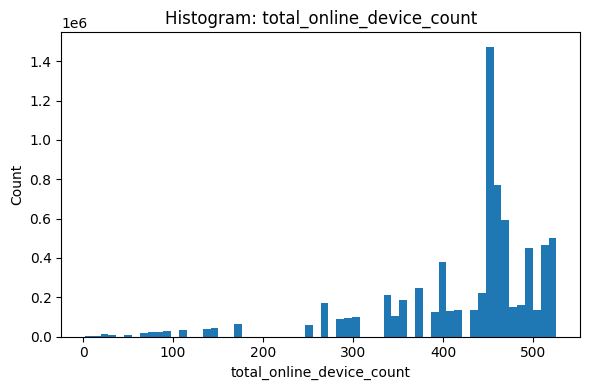

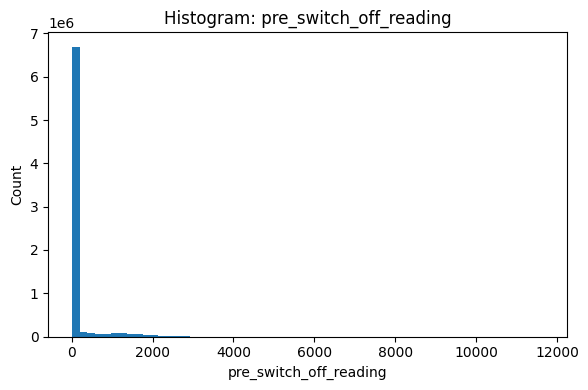

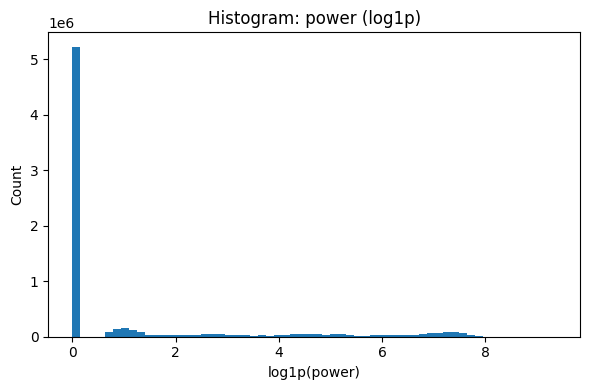

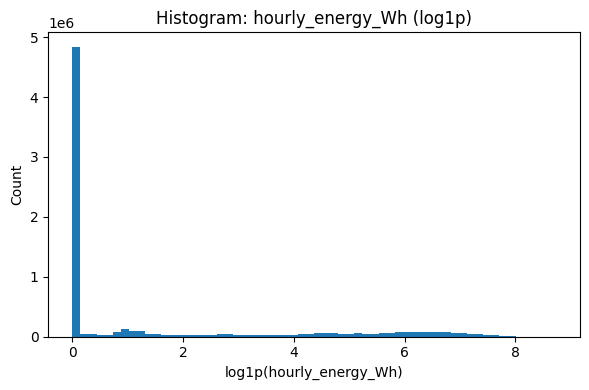

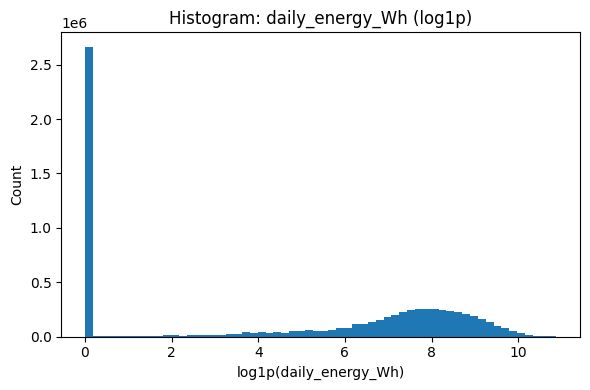

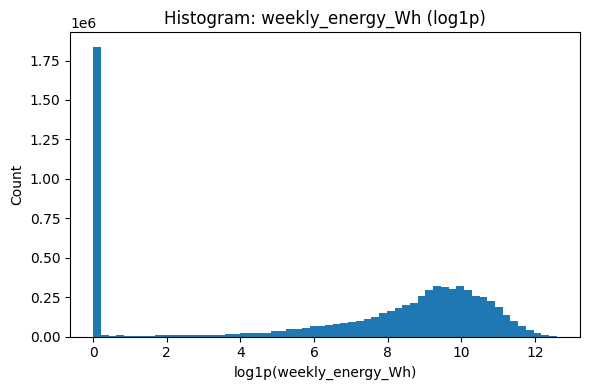

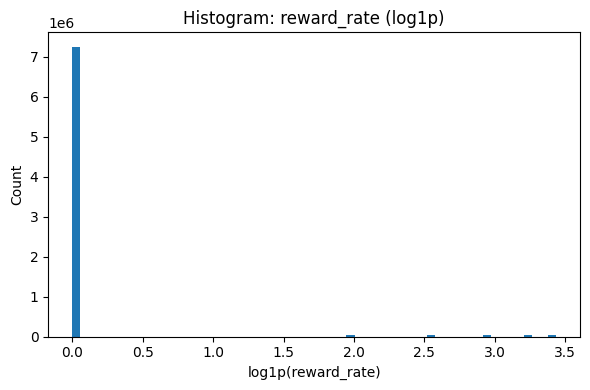

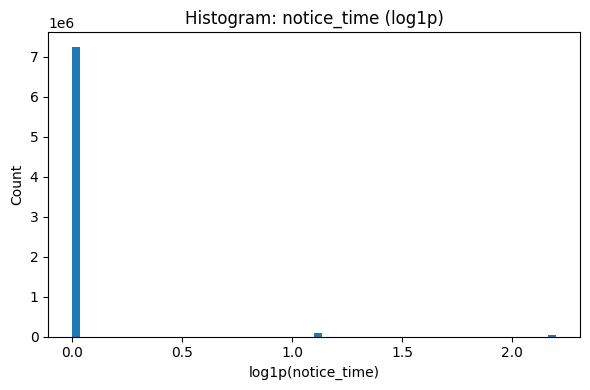

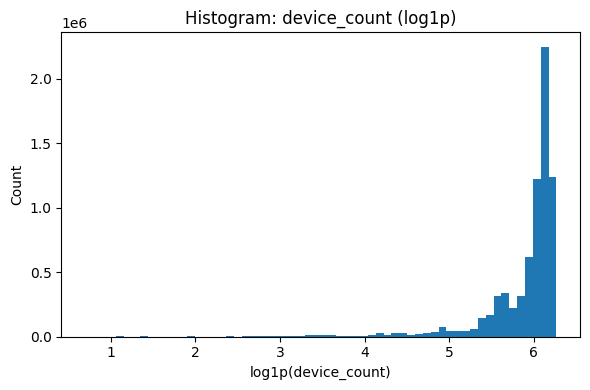

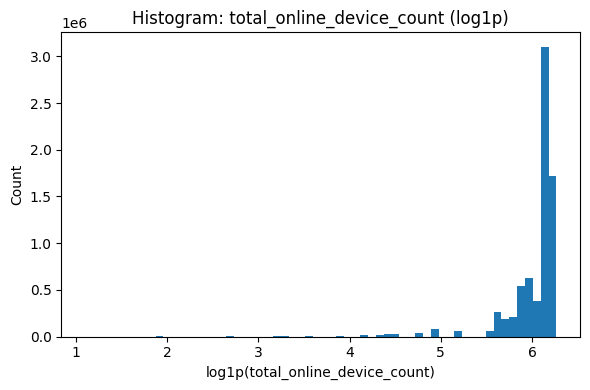

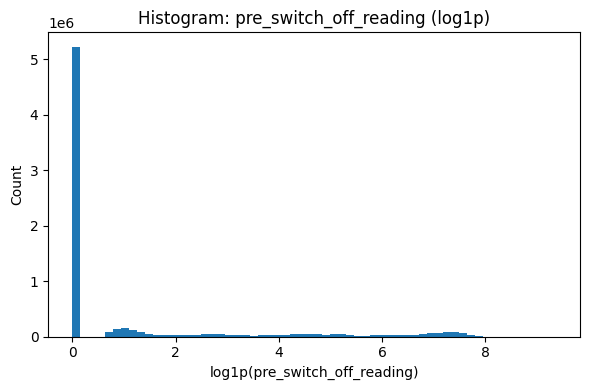

In [18]:

# --- Univariate distributions -----------------------------------------------
# Pick a short list of important numeric columns (edit as needed)
important_numeric = [c for c in ['power','total_power_Wh','hourly_energy_Wh','daily_energy_Wh','weekly_energy_Wh',
                                 'reward_rate','notice_time','device_count','total_installed_device_count',
                                 'total_online_device_count','pre_switch_off_reading'] if c in df.columns]

plot_histograms(df, cols=important_numeric, bins=60, log1p=False)
plot_histograms(df, cols=important_numeric, bins=60, log1p=True)


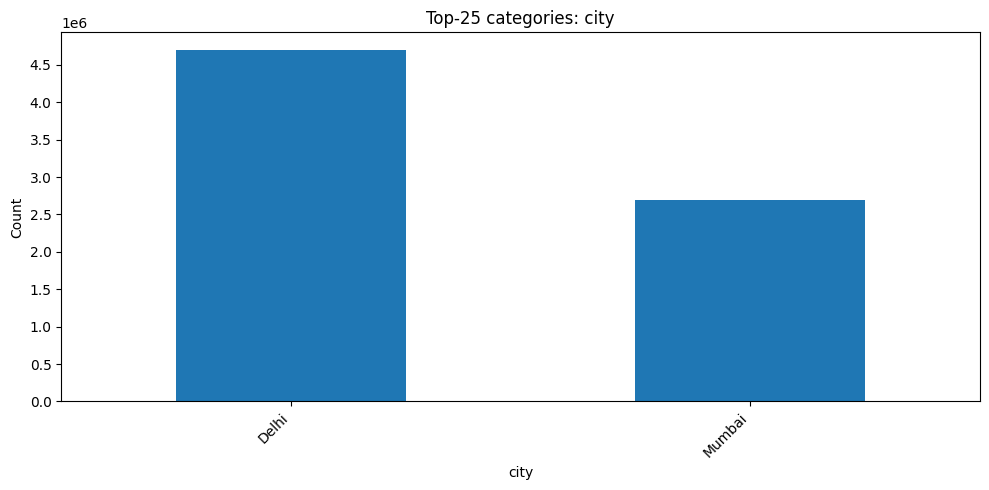

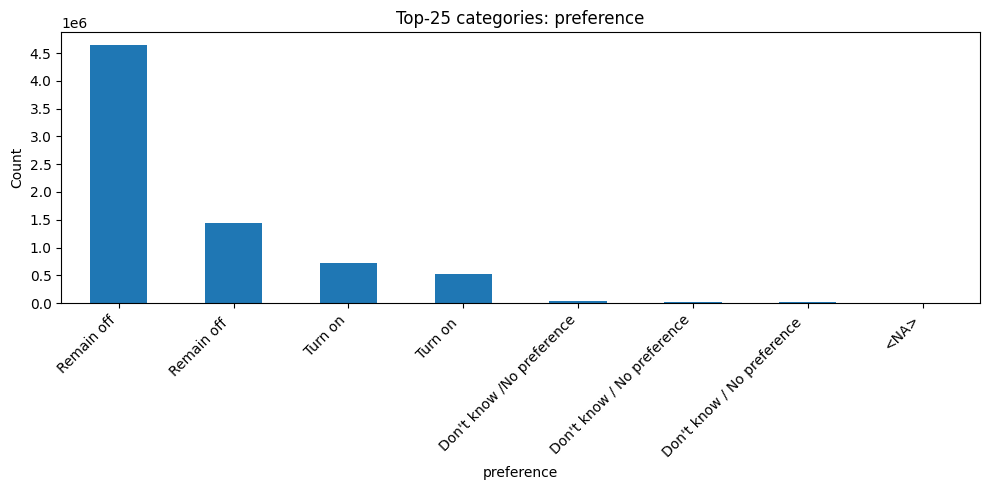

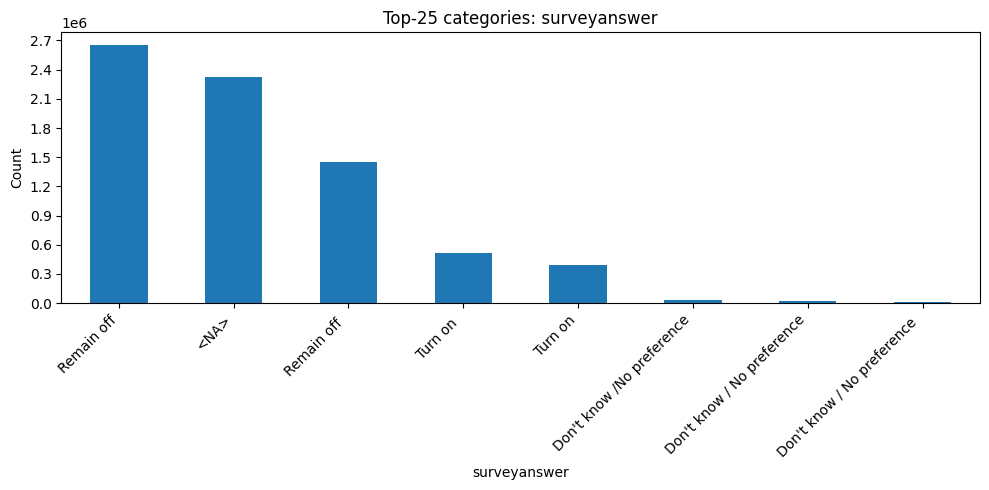

In [19]:

# Example categorical distributions (edit list as needed)
for cat in [c for c in ['city','device_type','preference','surveyanswer'] if c in df.columns]:
    plot_top_categories(df, cat, top_k=25)


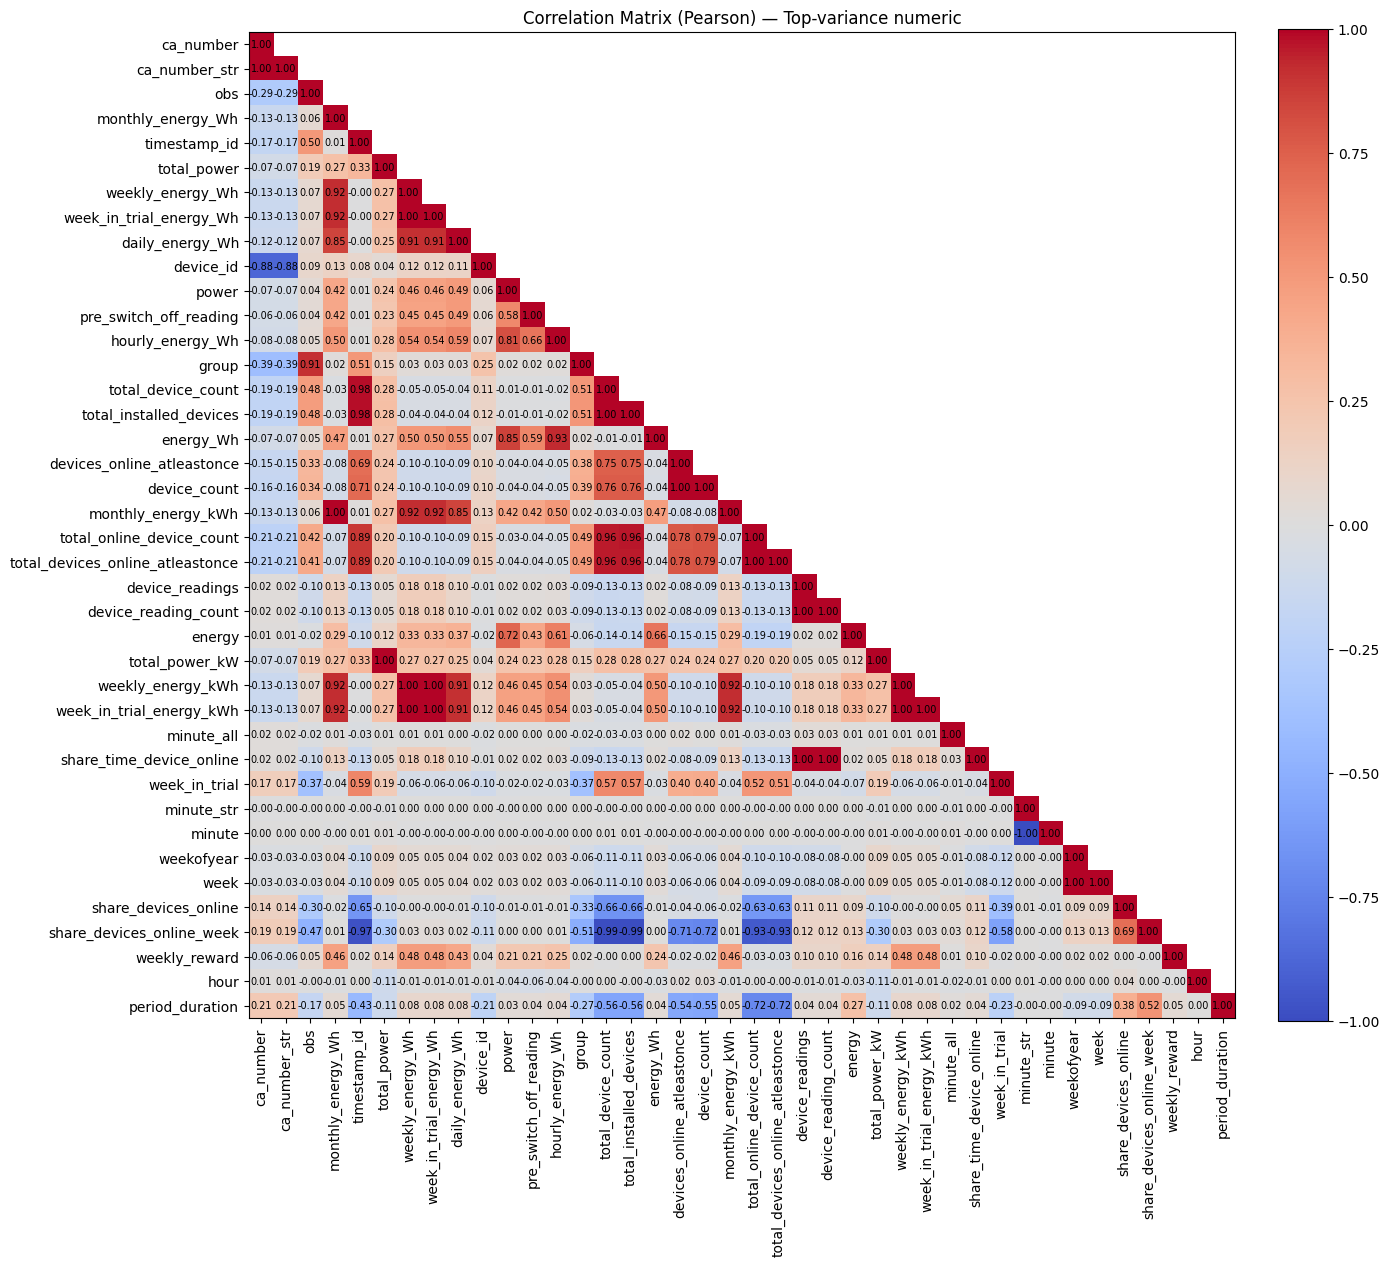

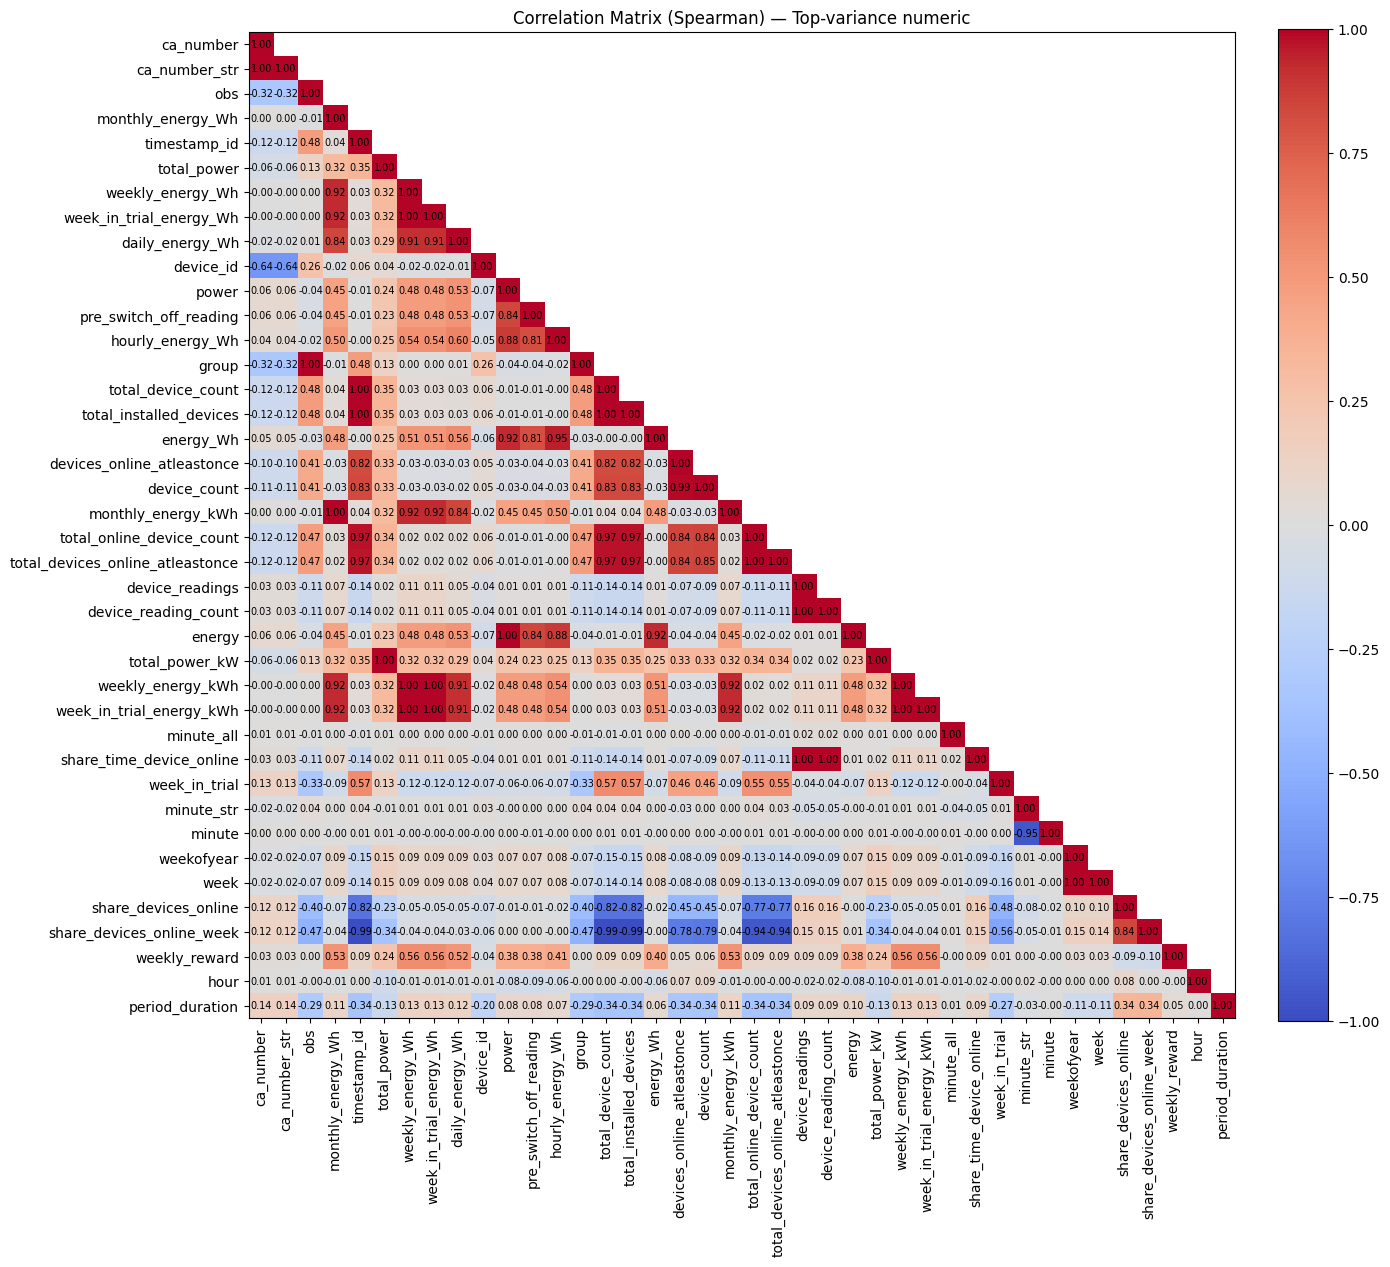

In [20]:

# --- Correlations ------------------------------------------------------------
corr_cols = select_numeric_for_corr(df, max_features=40, missing_threshold=0.5)
corr_pearson = compute_correlation(df, corr_cols, method='pearson', sample_n=400_000)
plot_correlation_heatmap(corr_pearson, title='Correlation Matrix (Pearson) — Top-variance numeric')

corr_spearman = compute_correlation(df, corr_cols, method='spearman', sample_n=400_000)
plot_correlation_heatmap(corr_spearman, title='Correlation Matrix (Spearman) — Top-variance numeric')


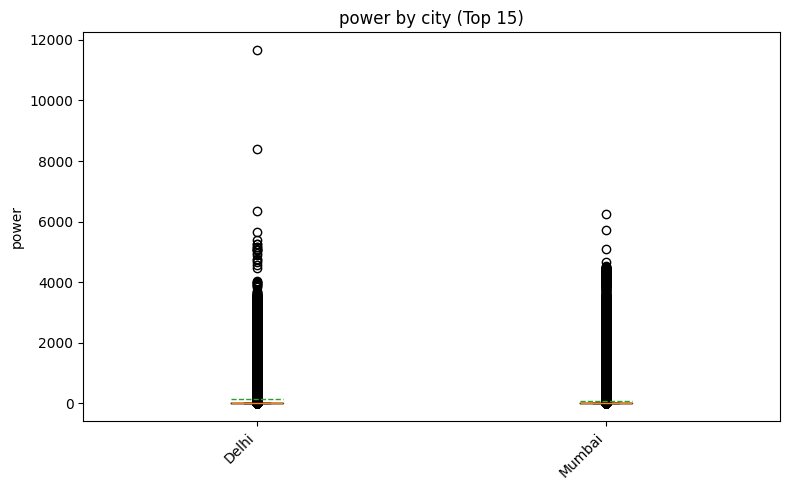

Cramér's V(city, override) = 0.010


In [22]:

# --- Categorical-numeric & categorical-categorical associations -------------
# Example: power by city; override by city; reward_rate by device_type
if 'city' in df.columns and 'power' in df.columns:
    plot_box_numeric_by_category(df, num_col='power', cat_col='city', top_k=15)

# Example Cramér's V between 'city' and 'override' (if both present)
if 'city' in df.columns and 'override' in df.columns:
    v = cramers_v(df['city'].astype('object'), df['override'].astype('object'))
    print(f"Cramér's V(city, override) = {v:0.3f}")


In [23]:

# --- Event-centric summaries -------------------------------------------------
event_summary = summarize_event_windows(df, value_col='power' if 'power' in df.columns else df.select_dtypes(include=[np.number]).columns[0])
event_summary


,segment,n_rows,mean_power,override_rate,event_rate,mean_reward_rate,mean_notice_time
0,in_window,2201823,94.865482,0.001953,0.006521,0.441482,0.091214
1,out_window,5189416,118.449566,0.000855,0.004401,0.308805,0.069046


In [24]:

pre_post_tbl = pre_post_event_delta(df, value_col='power' if 'power' in df.columns else df.select_dtypes(include=[np.number]).columns[0])
pre_post_tbl


,mean,std,min,25%,50%,75%,max
pre_switch_off_reading,92.807622,342.35734,0.0,0.0,0.0,1.24,8412.55957
power,94.865482,347.045822,0.0,0.0,0.0,1.31,8412.55957
delta,2.05786,329.826819,-5684.299805,0.0,0.0,0.0,8352.479492


In [26]:

# --- User-level aggregation (heterogeneity) ---------------------------------
user_value_cols = [c for c in ['power','total_power_Wh','reward','reward_rate'] if c in df.columns]
user_rate_cols = [c for c in ['override','actual_event'] if c in df.columns]

if 'user_id' in df.columns:
    df_user = user_level_summary(df, user_col='user_id', value_cols=user_value_cols, rate_cols=user_rate_cols)
    df_user.head(10)
    # Example user distributions
    for c in [col for col in ['power_mean','override_mean','reward_sum','reward_rate_mean'] if col in df_user.columns]:
        plot_user_distribution(df_user, c)




- `scikit‑learn` **Pipeline/ColumnTransformer** principles for modular preprocessing.

- For very large datasets, random **row sampling** for correlation is used to retain structure while reducing compute time (common EDA practice).





In [ ]:

# Save key artifacts for reporting (optional)
# schema_tbl.to_csv('outputs/schema_summary.csv', index=False)
# missing_tbl.to_csv('outputs/missing_summary.csv', index=False)
# if 'df_user' in globals():
#     df_user.to_csv('outputs/user_level_summary.csv', index=False)
